In [1]:
from datetime import datetime
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pickle
from datetime import datetime
import os
from pathlib import Path
import fsspec

import re
pd.set_option('display.max_columns', None)
sys.path.insert(0, os.path.abspath('../..'))
import repo_paths  # noqa: F401
%load_ext autoreload
%autoreload 2
from loading_runs import load_results_from_pickle, compute_rowwise_metrics, plot_mask_distributions, plot_metric_vs_lambda

In [2]:
def compute_rowwise_metrics(row, just_f1=True, bin_mask_column='binary_mask'):
    g = np.array(row['g_test'])        # shape (n, p)
    pred = np.array(row[bin_mask_column])
    
    # True Positives, False Positives, False Negatives per row
    TP = np.sum((pred == 1) & (g == 1), axis=1)
    FP = np.sum((pred == 1) & (g == 0), axis=1)
    FN = np.sum((pred == 0) & (g == 1), axis=1)
    
    # Compute metrics per row
    TPR = TP / (TP + FN + 1e-10)
    FDR = FP / (TP + FP + 1e-10)
    F1  = 2 * TP / (2 * TP + FP + FN + 1e-10)
    
    # Take mean across all rows in this experiment
    if just_f1 == True:
        return pd.Series({
                'F1' : np.mean(F1)
            })
    else:
        return pd.Series({
                'TPR': np.mean(TPR),
                'FDR': np.mean(FDR),
                'F1' : np.mean(F1)
            })

In [3]:
def find_switch_accuracy(row):
    switch_accuracy = (row['binary_mask'][:,-1] == row['g_test'][:,-1]).mean()
    return switch_accuracy

### Tuning

In [4]:
temp = load_results_from_pickle(folder='ICML_experiments/conditional_sampling/synthetic/tuning',
                                        time_threshold='25_09_03_12_00_00',
                                        keep_run_type=None,
                                          is_output=False,
                                  numeric_cols = ['rho','lmbda','accuracy', 'roc_auc', 'pct_sig','TPR_mean','FDR_mean','f1','pr_auc']
                                        )

assert (temp.num_syn_features == 11).all()

temp['F1'] = temp.apply(compute_rowwise_metrics, axis=1)

temp['switch_accuracy'] = temp.apply(lambda row: find_switch_accuracy(row),axis=1)

In [5]:
temp[['model','perturbation_method']].value_counts()

model      perturbation_method
Hide&Seek  conditional_rf         66
           knock_off              66
dtype: int64

In [58]:
assert (temp.model == "Hide&Seek").all()
temp['model']=temp['perturbation_method']

Forest sampling

In [59]:
pm = "conditional_rf"
a = (temp.query('model==@pm')
    .groupby(['model','lmbda'])
    [['TPR_mean','FDR_mean','f1','roc_auc','pr_auc','pct_sig']].mean().sort_values(by='roc_auc',ascending=False).reset_index()
    )
a[['model','lmbda','roc_auc','pr_auc','pct_sig']]

,model,lmbda,roc_auc,pr_auc,pct_sig
0,conditional_rf,0.2,0.832717,0.842932,0.358912
1,conditional_rf,0.3,0.830856,0.840866,0.350244
2,conditional_rf,0.1,0.829999,0.840872,0.480876
3,conditional_rf,0.4,0.828651,0.838570,0.343215
4,conditional_rf,0.5,0.824342,0.834493,0.329582
5,conditional_rf,0.6,0.819643,0.829930,0.312909
6,conditional_rf,0.0,0.818001,0.828693,0.993553
7,conditional_rf,0.7,0.813489,0.823842,0.296261
8,conditional_rf,0.8,0.808452,0.818714,0.287248
9,conditional_rf,0.9,0.787643,0.798763,0.263329


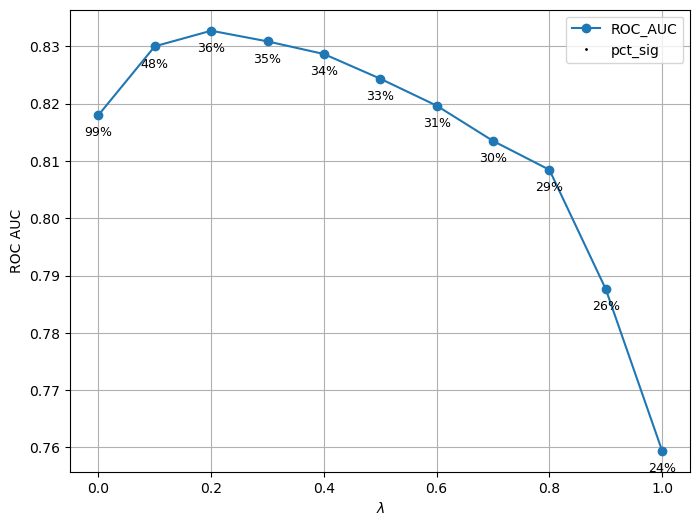

In [60]:
a_sorted = a.sort_values('lmbda')
my_ax = plot_metric_vs_lambda(a_sorted,
                              groupby_cols=None,
                              query='lmbda<2',
                              metric_col='roc_auc',
                              annotate_sig=True,
                             figsize=(8, 6))
plt.show()

Knockoffs

In [61]:
pm = "knock_off"
a = (temp.query('model==@pm')
    .groupby(['model','lmbda'])
    [['TPR_mean','FDR_mean','f1','roc_auc','pr_auc','pct_sig']].mean().sort_values(by='roc_auc',ascending=False).reset_index()
    )
a[['model','lmbda','roc_auc','pr_auc','pct_sig']]

,model,lmbda,roc_auc,pr_auc,pct_sig
0,knock_off,0.2,0.830767,0.841169,0.350989
1,knock_off,0.1,0.829613,0.840162,0.443489
2,knock_off,0.3,0.828694,0.839075,0.342053
3,knock_off,0.4,0.825782,0.836233,0.334362
4,knock_off,0.5,0.820668,0.831416,0.319167
5,knock_off,0.0,0.819635,0.829604,0.992508
6,knock_off,0.6,0.815706,0.826754,0.305845
7,knock_off,0.7,0.807423,0.819138,0.285162
8,knock_off,0.8,0.796230,0.808452,0.265436
9,knock_off,0.9,0.772819,0.787657,0.230145


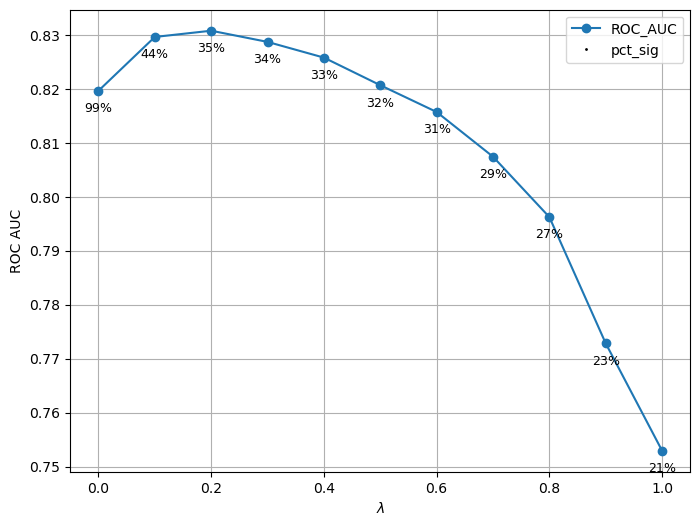

In [62]:
a_sorted = a.sort_values('lmbda')
my_ax = plot_metric_vs_lambda(a_sorted,
                              groupby_cols=None,
                              query='lmbda<2',
                              metric_col='roc_auc',
                              annotate_sig=True,
                             figsize=(8, 6))
plt.show()

The tuning curves have the same shape as the marginal sampling. Therefore, we will choose the same $\lambda$ as in the marginal sampling: 0.3. For the same reasons: high accuracy with high parsimony.

## Test

In [4]:
temp = load_results_from_pickle(folder='ICML_experiments/conditional_sampling/synthetic/test',
                                        time_threshold='25_09_03_12_00_00',
                                        keep_run_type=None,
                                          is_output=False,
                                  numeric_cols = ['rho','lmbda','accuracy', 'roc_auc', 'pct_sig','TPR_mean','FDR_mean','f1','pr_auc']
                                        )

assert (temp.num_syn_features == 11).all()

temp['F1'] = temp.apply(compute_rowwise_metrics, axis=1)

temp['switch_accuracy'] = temp.apply(lambda row: find_switch_accuracy(row),axis=1)
assert (temp.model == "Hide&Seek").all()
assert temp.rho.isna().all()
assert (temp.lmbda==0.3).all()

In [5]:
temp[['model','perturbation_method','syn']].value_counts()

model      perturbation_method  syn 
Hide&Seek  conditional_rf       Syn1    20
                                Syn2    20
                                Syn3    20
                                Syn4    20
                                Syn5    20
                                Syn6    20
           knock_off            Syn1    20
                                Syn2    20
                                Syn3    20
                                Syn4    20
                                Syn5    20
                                Syn6    20
dtype: int64

In [6]:
print(temp.groupby(['model','perturbation_method','syn'])[['TPR_mean','FDR_mean']].median().round(0))

                                    TPR_mean  FDR_mean
model     perturbation_method syn                     
Hide&Seek conditional_rf      Syn1     100.0       0.0
                              Syn2     100.0       0.0
                              Syn3      99.0       0.0
                              Syn4      99.0       4.0
                              Syn5      97.0       3.0
                              Syn6      98.0       4.0
          knock_off           Syn1      99.0       0.0
                              Syn2     100.0       0.0
                              Syn3      98.0       0.0
                              Syn4      99.0       4.0
                              Syn5      96.0       3.0
                              Syn6      89.0       4.0


Forest sammpling is identical to the marginal method

## Correlated

Because the tuning curves matched the marginal above, we're going to use the already determined $\lambda$ in the correlated experiment for this as well. Namely {$\rho$: $\lambda$}:

{0.0: 0.5,
  0.1: 0.5,
  0.2: 0.3,
  0.3: 0.5,
  0.4: 0.3,
  0.5: 0.3,
  0.6: 0.1,
  0.7: 0.1,
  0.8: 0.1,
  0.9: 0.1,
  1.0: 0.1}


In [4]:
temp = load_results_from_pickle(folder='ICML_experiments/conditional_sampling/synthetic/correlated',
                                        time_threshold='25_09_03_12_00_00',
                                        keep_run_type=None,
                                          is_output=False,
                                  numeric_cols = ['rho','lmbda','accuracy', 'roc_auc', 'pct_sig','TPR_mean','FDR_mean','f1','pr_auc']
                                        )

assert (temp.num_syn_features == 11).all()

temp['F1'] = temp.apply(compute_rowwise_metrics, axis=1)

temp['switch_accuracy'] = temp.apply(lambda row: find_switch_accuracy(row),axis=1)
assert (temp.model == "Hide&Seek").all()
assert (temp.groupby(['rho','syn','perturbation_method'])['lmbda'].count()==1).all()

In [5]:
desired_rho_lmbda_dict = {0.0: 0.5,
  0.1: 0.5,
  0.2: 0.3,
  0.3: 0.5,
  0.4: 0.3,
  0.5: 0.3,
  0.6: 0.1,
  0.7: 0.1,
  0.8: 0.1,
  0.9: 0.1,
  1.0: 0.1}
runs_rho_lmbda_dict = temp[['rho','lmbda']].drop_duplicates().set_index('rho').to_dict()['lmbda']
assert desired_rho_lmbda_dict == runs_rho_lmbda_dict

In [6]:
b = temp.groupby(['model','perturbation_method','rho','lmbda'])[['TPR_mean','FDR_mean','f1','roc_auc','pr_auc','pct_sig']].mean().reset_index()
b

,model,perturbation_method,rho,lmbda,TPR_mean,FDR_mean,f1,roc_auc,pr_auc,pct_sig
0,Hide&Seek,conditional_rf,0.0,0.5,93.254028,0.980750,95.092210,0.824342,0.834493,0.329582
1,Hide&Seek,conditional_rf,0.1,0.5,91.687305,0.950778,94.240551,0.821571,0.828674,0.321724
2,Hide&Seek,conditional_rf,0.2,0.3,97.511861,1.469070,97.813368,0.828261,0.830231,0.345471
3,Hide&Seek,conditional_rf,0.3,0.5,86.119222,0.698528,90.299766,0.811805,0.813986,0.304871
4,Hide&Seek,conditional_rf,0.4,0.3,93.979694,1.150825,95.779257,0.821450,0.821255,0.329667
5,Hide&Seek,conditional_rf,0.5,0.3,86.327333,0.910435,90.333544,0.806319,0.810230,0.307918
6,Hide&Seek,conditional_rf,0.6,0.1,93.943472,3.205292,94.608575,0.819628,0.817582,0.345074
7,Hide&Seek,conditional_rf,0.7,0.1,87.418166,2.050657,91.265468,0.805398,0.804515,0.310656
8,Hide&Seek,conditional_rf,0.8,0.1,76.112305,1.770516,81.206958,0.763293,0.764635,0.275761
9,Hide&Seek,conditional_rf,0.9,0.1,42.692194,1.581833,51.974864,0.703120,0.733528,0.163226


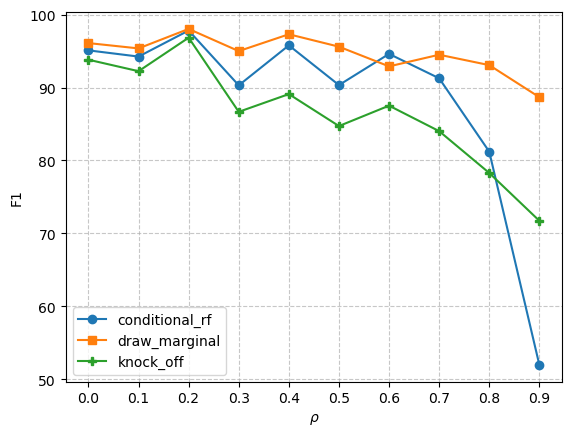

In [7]:
import itertools

# Specify your desired path here
# save_path = os.path.join(os.path.abspath('..'), 'figures', 'correlated.pdf') 
# save_path = os.path.expanduser(save_path)

plt.figure() # Optional: makes the chart slightly wider and easier to read


markers = itertools.cycle(['o', 's', 'P','v', 'D', '^'])

for model, g in b.query('rho!=1').groupby('perturbation_method'):
    g = g.sort_values('rho')
    plt.plot(
        g['rho'], g['f1'], 
        marker=next(markers), 
        markersize=6, 
        label=model
    )
plt.rcParams.update({
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

plt.xlabel(r'$\rho$')
plt.ylabel('F1')
plt.legend()

# 1. Force the x-axis ticks to be every 0.1 from 0 to 1
plt.xticks(np.arange(0, 1, 0.1)) 

# 2. Add grid lines (added styling makes it look a bit cleaner)
plt.grid(True, linestyle='--', alpha=0.7)

# 3. Save as a PDF (bbox_inches='tight' prevents the labels from getting cut off)
# plt.savefig(save_path, format='pdf', bbox_inches='tight')

# Show the plot
plt.show()

Although this is only one run, conditional_rf seems to fail when $\rho=0.9$. Investigation shows it comes from a drop in TPR. Quite likely, when $\rho=0.9$, it becomes easy to predict an important feature from the other features, which is what conditional_rf does. This means the feature is not identified as important and the TPR drops.

We ended up deciding to only include the knockoff method in the paper

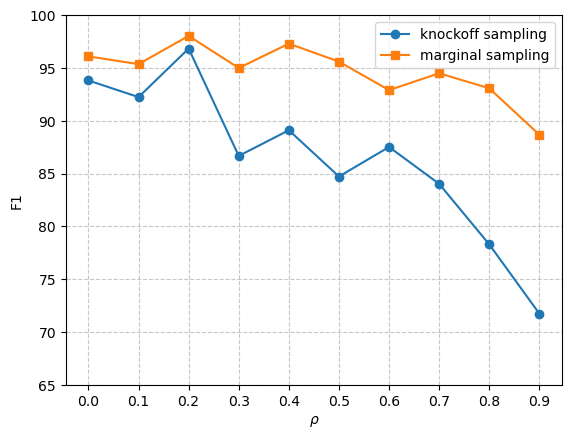

In [8]:

c = b.copy()
pert_replace = {'draw_marginal': 'marginal sampling', 'knock_off': 'knockoff sampling'}
c['perturbation_method'] = c['perturbation_method'].replace(pert_replace)
c = c.sort_values(by=['rho','perturbation_method'])
import itertools

# # Specify your desired path here
# save_path = os.path.join(os.path.abspath('..'), 'figures', 'correlated_knockoff.pdf') 
# save_path = os.path.expanduser(save_path)

plt.figure() # Optional: makes the chart slightly wider and easier to read


markers = itertools.cycle(['o', 's', 'P','v', 'D', '^'])

for model, g in c.query('(rho!=1) & (perturbation_method!="conditional_rf")').groupby('perturbation_method'):
    g = g.sort_values('rho')
    plt.plot(
        g['rho'], g['f1'], 
        marker=next(markers), 
        markersize=6, 
        label=model
    )

plt.rcParams.update({
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

plt.xlabel(r'$\rho$')
plt.ylabel('F1')
plt.ylim(65,100)

plt.legend()
# 1. Force the x-axis ticks to be every 0.1 from 0 to 1
plt.xticks(np.arange(0, 1, 0.1)) 

# 2. Add grid lines (added styling makes it look a bit cleaner)
plt.grid(True, linestyle='--', alpha=0.7)

# 3. Save as a PDF (bbox_inches='tight' prevents the labels from getting cut off)
# plt.savefig(save_path, format='pdf', bbox_inches='tight')

# Show the plot
plt.show()

fixing coloring

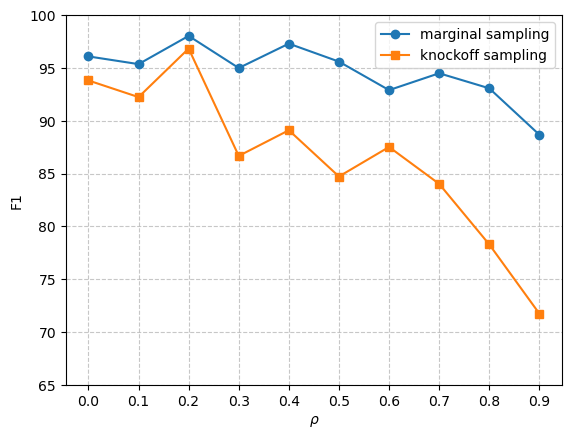

In [9]:
c = b.copy()
pert_replace = {'draw_marginal': 'marginal sampling', 'knock_off': 'knockoff sampling'}
c['perturbation_method'] = c['perturbation_method'].replace(pert_replace)
c = c.sort_values(by=['rho','perturbation_method'])
import itertools

# Specify your desired path here
save_path = os.path.join(os.path.abspath('..'), 'figures', 'correlated_knockoff.pdf') 
save_path = os.path.expanduser(save_path)

plt.figure() # Optional: makes the chart slightly wider and easier to read

plt.rcParams.update({
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

color_map = {
    'marginal sampling': 'tab:blue', 
    'knockoff sampling': 'tab:orange'
}

markers = itertools.cycle(['s','o'])

for model, g in c.query('(rho!=1) & (perturbation_method!="conditional_rf")').groupby('perturbation_method'):
    g = g.sort_values('rho')
    plt.plot(
        g['rho'], g['f1'], 
        marker=next(markers),
        color=color_map.get(model, 'black'), # Assigns the specific color, defaults to black if not found
        markersize=6, 
        label=model
    )

plt.xlabel(r'$\rho$')
plt.ylabel('F1')
plt.ylim(65,100)



# 1. Get the current handles (the marker/line graphics) and labels (the text)
handles, labels = plt.gca().get_legend_handles_labels()

# 2. Find the index of 'marginal sampling' and move it to the front
marginal_idx = labels.index('marginal sampling')
new_order = [marginal_idx] + [i for i in range(len(labels)) if i != marginal_idx]

# 3. Create the legend using the new custom order
plt.legend([handles[idx] for idx in new_order], [labels[idx] for idx in new_order])

# 1. Force the x-axis ticks to be every 0.1 from 0 to 1
plt.xticks(np.arange(0, 1, 0.1)) 

# 2. Add grid lines (added styling makes it look a bit cleaner)
plt.grid(True, linestyle='--', alpha=0.7)

# 3. Save as a PDF (bbox_inches='tight' prevents the labels from getting cut off)
plt.savefig(save_path, format='pdf', bbox_inches='tight')

# Show the plot
plt.show()